In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('user_nutritional_data.csv')
df.head()

,Gender,Age,Daily meals frequency,Physical exercise,Height,Weight,BMR,Carbs,Proteins,Fats,Calories
0,0,29,3,0,165,101.0,1901.25,285.188,114.075,76.050,2281.502
1,1,25,3,4,165,53.0,1275.25,302.872,121.149,80.766,2422.978
2,0,23,2,0,170,70.0,1652.50,247.875,99.150,66.100,1983.000
3,0,22,3,0,168,112.0,2065.00,309.750,123.900,82.600,2478.000
4,0,19,3,2,175,67.0,1673.75,324.289,129.716,86.477,2594.313


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 2182 non-null   int64  
 1   Age                    2182 non-null   int64  
 2   Daily meals frequency  2182 non-null   int64  
 3   Physical exercise      2182 non-null   int64  
 4   Height                 2182 non-null   int64  
 5   Weight                 2182 non-null   float64
 6   BMR                    2182 non-null   float64
 7   Carbs                  2182 non-null   float64
 8   Proteins               2182 non-null   float64
 9   Fats                   2182 non-null   float64
 10  Calories               2182 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 187.6 KB


In [4]:
df.describe()

,Gender,Age,Daily meals frequency,Physical exercise,Height,Weight,BMR,Carbs,Proteins,Fats,Calories
count,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000
mean,0.420257,26.752062,2.869844,0.489459,162.763520,73.814207,1556.891155,250.358567,100.143417,66.762272,2002.868384
std,0.493713,8.425983,0.624663,1.012815,10.123945,20.837370,270.809953,56.031911,22.412771,14.941842,448.255305
min,0.000000,15.000000,2.000000,0.000000,122.000000,35.000000,861.500000,129.225000,51.690000,34.460000,1033.800000
25%,0.000000,22.000000,2.000000,0.000000,157.000000,56.000000,1350.000000,207.412000,82.965000,55.310000,1659.298000
50%,0.000000,24.000000,3.000000,0.000000,163.000000,72.000000,1548.250000,242.925000,97.170000,64.780000,1943.400000
75%,1.000000,28.000000,3.000000,1.000000,170.000000,89.000000,1742.500000,285.748000,114.299250,76.199500,2285.984500
max,1.000000,75.000000,4.000000,4.000000,188.000000,150.000000,2408.750000,461.047000,184.419000,122.946000,3688.378000


# Outlier Detection

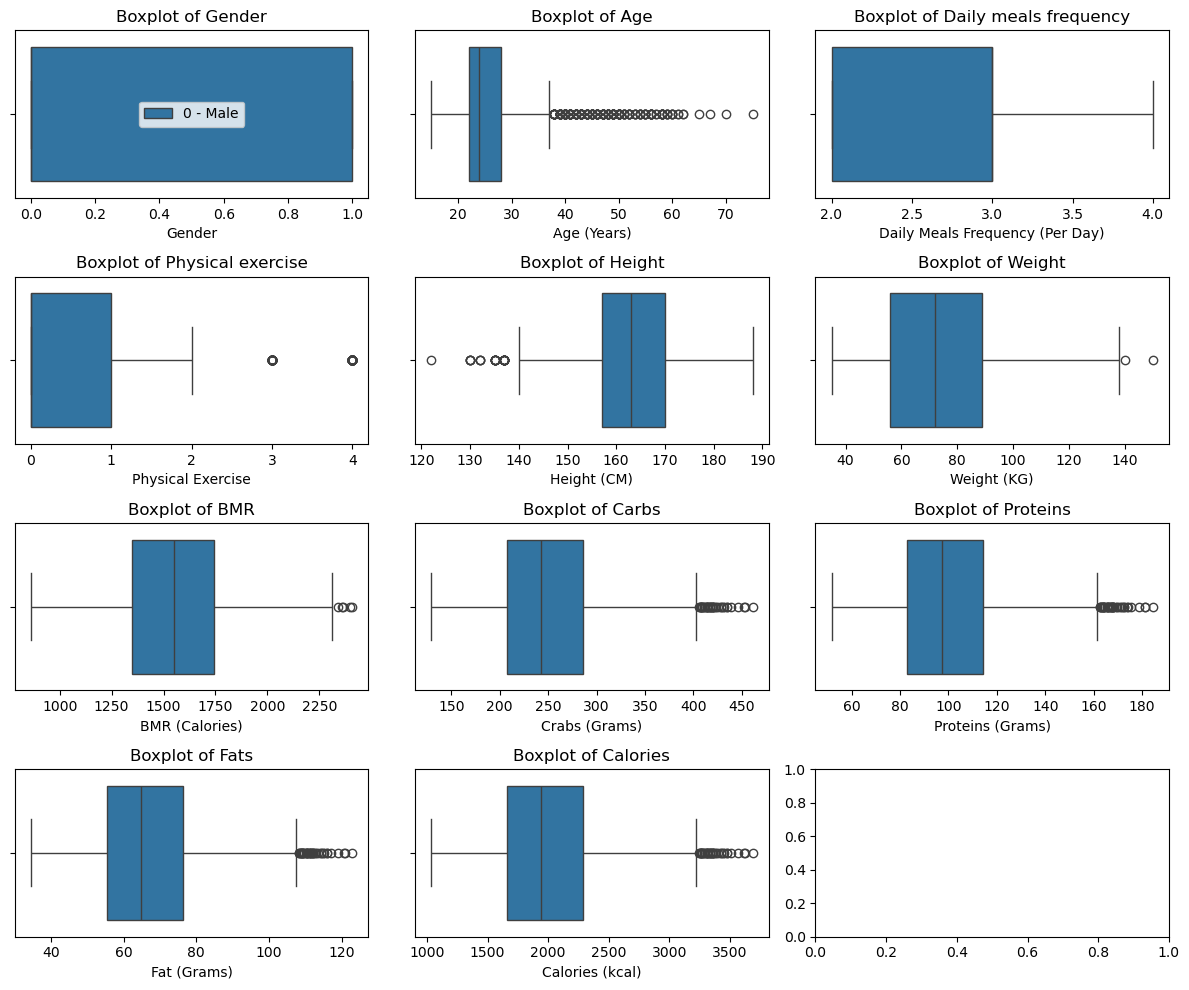

In [5]:
fig, axes = plt.subplots(4,3,figsize=(12,10))

sns.boxplot(x=df['Gender'],ax=axes[0,0])
axes[0,0].set_title("Boxplot of Gender")
axes[0,0].set_xlabel("Gender")
axes[0,0].legend(["0 - Male","1 - Female"])


sns.boxplot(x=df['Age'],ax=axes[0,1])
axes[0,1].set_title("Boxplot of Age")
axes[0,1].set_xlabel("Age (Years)")


sns.boxplot(x=df['Daily meals frequency'],ax=axes[0,2])
axes[0,2].set_title("Boxplot of Daily meals frequency")
axes[0,2].set_xlabel("Daily Meals Frequency (Per Day)")


sns.boxplot(x=df['Physical exercise'],ax=axes[1,0])
axes[1,0].set_title("Boxplot of Physical exercise")
axes[1,0].set_xlabel("Physical Exercise")


sns.boxplot(x=df['Height'],ax=axes[1,1])
axes[1,1].set_title("Boxplot of Height")
axes[1,1].set_xlabel("Height (CM)")


sns.boxplot(x=df['Weight'],ax=axes[1,2])
axes[1,2].set_title("Boxplot of Weight")
axes[1,2].set_xlabel("Weight (KG)")


sns.boxplot(x=df['BMR'],ax=axes[2,0])
axes[2,0].set_title("Boxplot of BMR")
axes[2,0].set_xlabel("BMR (Calories)")


sns.boxplot(x=df['Carbs'],ax=axes[2,1])
axes[2,1].set_title("Boxplot of Carbs")
axes[2,1].set_xlabel("Crabs (Grams)")

sns.boxplot(x=df['Proteins'],ax=axes[2,2])
axes[2,2].set_title("Boxplot of Proteins")
axes[2,2].set_xlabel("Proteins (Grams)")


sns.boxplot(x=df['Fats'],ax=axes[3,0])
axes[3,0].set_title("Boxplot of Fats")
axes[3,0].set_xlabel("Fat (Grams)")


sns.boxplot(x=df['Calories'],ax=axes[3,1])
axes[3,1].set_title("Boxplot of Calories")
axes[3,1].set_xlabel("Calories (kcal)")


plt.tight_layout()
plt.show()

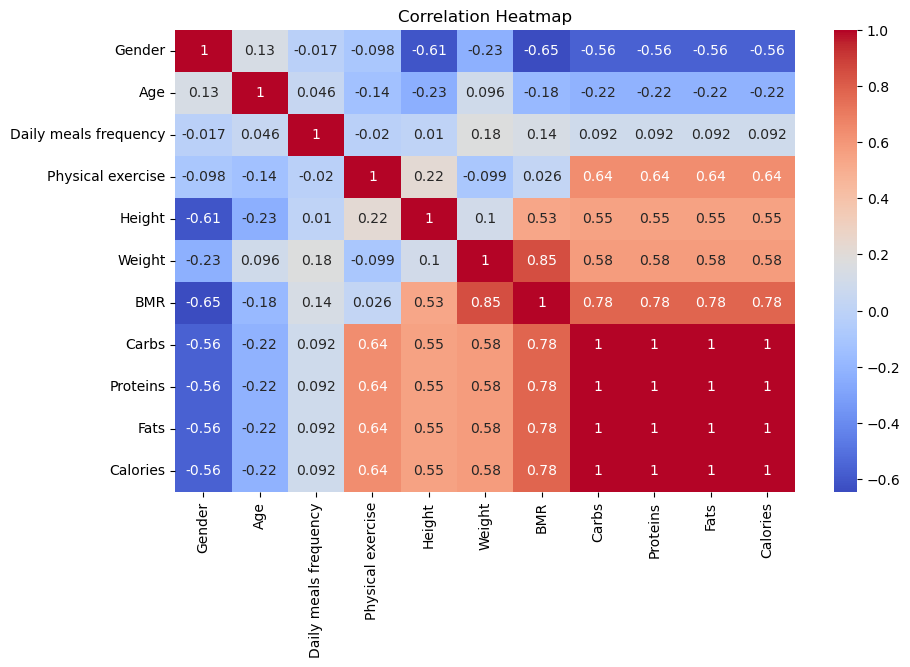

In [6]:
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Features and Target

In [7]:
# Dependent Variable : Gender, Age, Height, Weight, BMR, Carbs, proteins, Fats
# Independet Variable : Calories

# X = df[["Gender", "Age", "Height", "Weight"]]   # independent variables
# Y = df[["Carbs", "Proteins", "Fats", "Calories"]]  # dependent variables

In [8]:
# X = df[['Gender', 'Age', 'Height', 'Weight', 'BMR', 'Carbs', 'Proteins', 'Fats']]


X = df[['Gender', 'Age', 'Height', 'Weight', 'BMR']]
Y = df['Calories']

# Traning Dataset And Testing Dataset

In [9]:
X_train, X_test, Y_train,Y_test = train_test_split( X, Y, test_size = 0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1745, 5)
Testing data shape: (437, 5)


# Standardization

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pipeline

In [11]:
# print("\nTraining Linear Regression...")
# lr_pipeline.fit(X_train, Y_train)

# print("Training SVM Regression (SVR)...")
# svr_pipeline.fit(X_train, Y_train)

# Linear Regression

In [12]:
reg = linear_model.LinearRegression()
reg.fit(X_train, Y_train)

LinearRegression()

In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)
y_pred_lr = lr_model.predict(X_test)

In [14]:
# regression coefficients
print('Coefficients: ', reg.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_test, Y_test)))

Coefficients:  [-48.43758111 -47.91468987 122.07987306 119.44574266 143.53733225]
Variance score: 0.6473995113922726


In [15]:
y_pred_lr = reg.predict(X_test)


# Compute metrics for Linear Regression
r2_lr = r2_score(Y_test, y_pred_lr)
mse_lr = mean_squared_error(Y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(Y_test, y_pred_lr)
within_tol_lr = np.abs(Y_test - y_pred_lr) <= 0.10 * np.abs(Y_test)
accuracy_pct_lr = 100.0 * np.mean(within_tol_lr)

In [16]:
print("\nLinear Regression")
print(f"  R²       : {r2_lr:.4f}")
print(f"  RMSE     : {rmse_lr:.4f}")
print(f"  MAE      : {mae_lr:.4f}")
print(f"  ACCURACY : {accuracy_pct_lr:.2f}% ({within_tol_lr.sum()}/{len(Y_test)})")


Linear Regression
  R²       : 0.6474
  RMSE     : 266.6711
  MAE      : 185.2169
  ACCURACY : 69.57% (304/437)


# Support Vector Machine

In [17]:
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train, Y_train)

SVR()

In [18]:
# Predict
y_pred_svr = svm_model.predict(X_test)

In [19]:
# Compute metrics for SVM Regression
r2_svr = r2_score(Y_test, y_pred_svr)
mse_svr = mean_squared_error(Y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(Y_test, y_pred_svr)
within_tol_svr = np.abs(Y_test - y_pred_svr) <= 0.10 * np.abs(Y_test)
accuracy_pct_svr = 100.0 * np.mean(within_tol_svr)


In [20]:
print("\nSVM Regression (SVR)")
print(f"  R²       : {r2_svr:.4f}")
print(f"  RMSE     : {rmse_svr:.4f}")
print(f"  MAE      : {mae_svr:.4f}")
print(f"  ACCURACY : {accuracy_pct_svr:.2f}% ({within_tol_svr.sum()}/{len(Y_test)})")


SVM Regression (SVR)
  R²       : 0.3929
  RMSE     : 349.9307
  MAE      : 234.8506
  ACCURACY : 52.63% (230/437)


# KNN

In [21]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, Y_train)

KNeighborsRegressor()

In [22]:
# Predict
y_pred_knn = knn_model.predict(X_test)

In [23]:
# Compute metrics for SVM Regression
r2_knn = r2_score(Y_test, y_pred_knn)
mse_knn = mean_squared_error(Y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(Y_test, y_pred_knn)
within_tol_knn = np.abs(Y_test - y_pred_knn) <= 0.10 * np.abs(Y_test)
accuracy_pct_knn = 100.0 * np.mean(within_tol_knn)

In [24]:
print("\nKNN Regression")
print(f"  R²       : {r2_knn:.4f}")
print(f"  RMSE     : {rmse_knn:.4f}")
print(f"  MAE      : {mae_knn:.4f}")
print(f"  ACCURACY : {accuracy_pct_knn:.2f}% ({within_tol_knn.sum()}/{len(Y_test)})")


KNN Regression
  R²       : 0.6524
  RMSE     : 264.7660
  MAE      : 166.0031
  ACCURACY : 70.48% (308/437)


In [25]:
print("\n--- Predict Calories from Custom Input ---")
sample_gender = 0
sample_age    = 16
sample_height = 157
sample_weight = 73
sample_bmr    = 1636.25


# Create DataFrame
sample = pd.DataFrame([[sample_gender, sample_age, sample_height, sample_weight, sample_bmr]],
                      columns=['Gender','Age','Height','Weight','BMR'])
sample_scaled = scaler.transform(sample)

pred_lr  = reg.predict(sample_scaled)[0]
pred_svr = svm_model.predict(sample_scaled)[0]
pred_knn = knn_model.predict(sample_scaled)[0]

print(f"\nInput: Gender={sample_gender}, Age={sample_age}, Height={sample_height}, Weight={sample_weight}, BMR={sample_bmr}")
print(f"Predicted Calories (Linear Regression): {pred_lr:.2f}")
print(f"Predicted Calories (SVR)              : {pred_svr:.2f}")
print(f"Predicted Calories (KNN)              : {pred_knn:.2f}")



--- Predict Calories from Custom Input ---

Input: Gender=0, Age=16, Height=157, Weight=73, BMR=1636.25
Predicted Calories (Linear Regression): 2072.74
Predicted Calories (SVR)              : 1942.65
Predicted Calories (KNN)              : 2132.63


# Plotting

### 1️. Predicted vs Actual

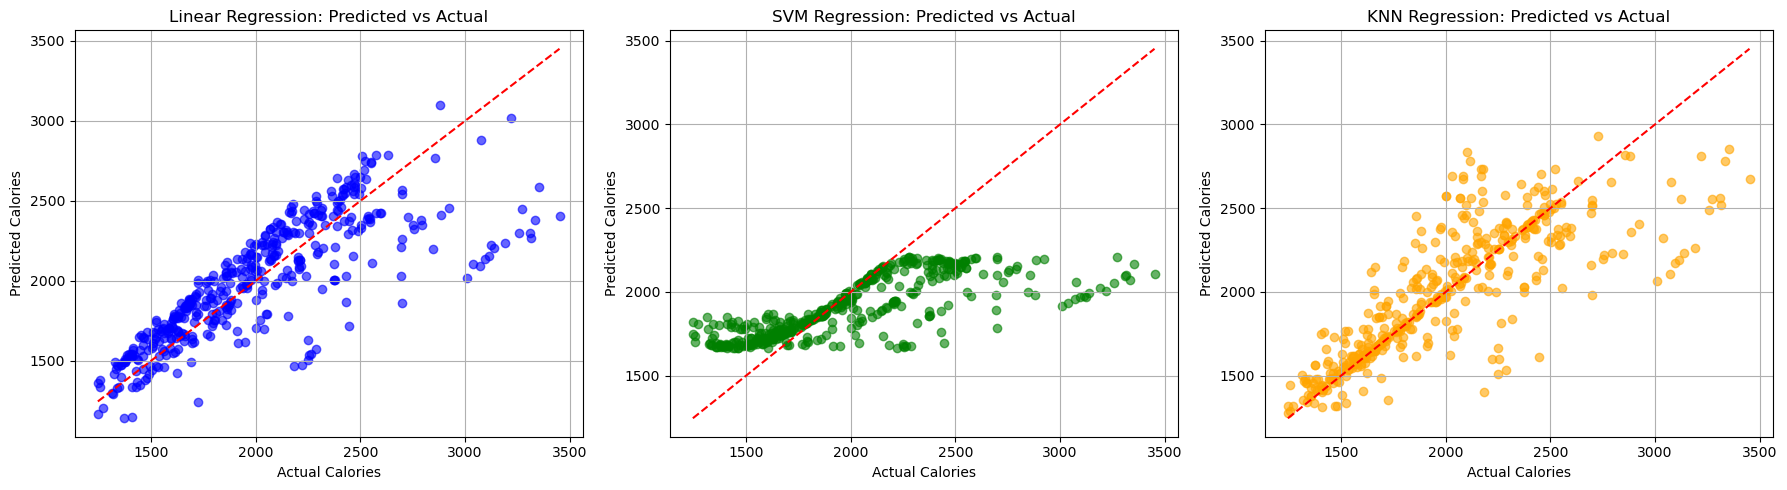

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# 1️⃣ Linear Regression
plt.subplot(1,3,1)
plt.scatter(Y_test, y_pred_lr, color='blue', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Linear Regression: Predicted vs Actual')
plt.grid(True)

# 2️⃣ SVM Regression
plt.subplot(1,3,2)
plt.scatter(Y_test, y_pred_svr, color='green', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('SVM Regression: Predicted vs Actual')
plt.grid(True)

# 3️⃣ KNN Regression
plt.subplot(1,3,3)
plt.scatter(Y_test, y_pred_knn, color='orange', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('KNN Regression: Predicted vs Actual')
plt.grid(True)

plt.tight_layout()
plt.show()


### Residuals (Actual - Predicted)

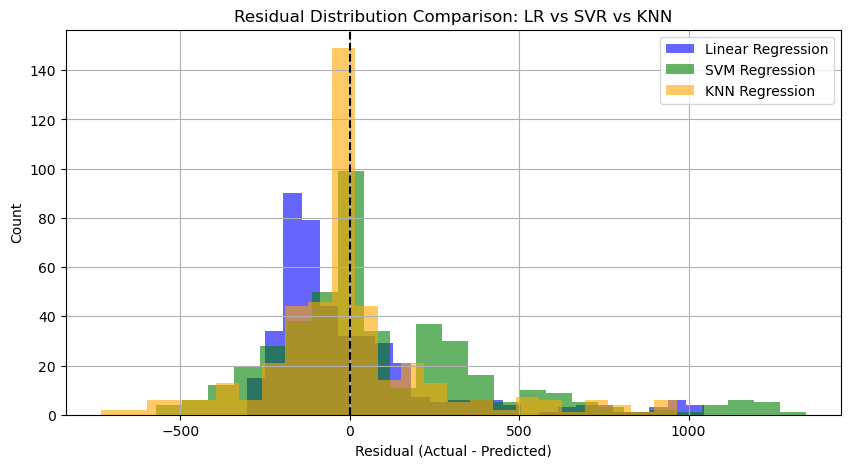

In [27]:
# Calculate residuals (Actual - Predicted)
residuals_lr  = Y_test - y_pred_lr
residuals_svr = Y_test - y_pred_svr
residuals_knn = Y_test - y_pred_knn

# Plot residual histograms
plt.figure(figsize=(10,5))
plt.hist(residuals_lr,  bins=25, alpha=0.6, label='Linear Regression', color='blue')
plt.hist(residuals_svr, bins=25, alpha=0.6, label='SVM Regression', color='green')
plt.hist(residuals_knn, bins=25, alpha=0.6, label='KNN Regression', color='orange')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Residual Distribution Comparison: LR vs SVR vs KNN')
plt.legend()
plt.grid(True)
plt.show()


### Residuals vs Predicted

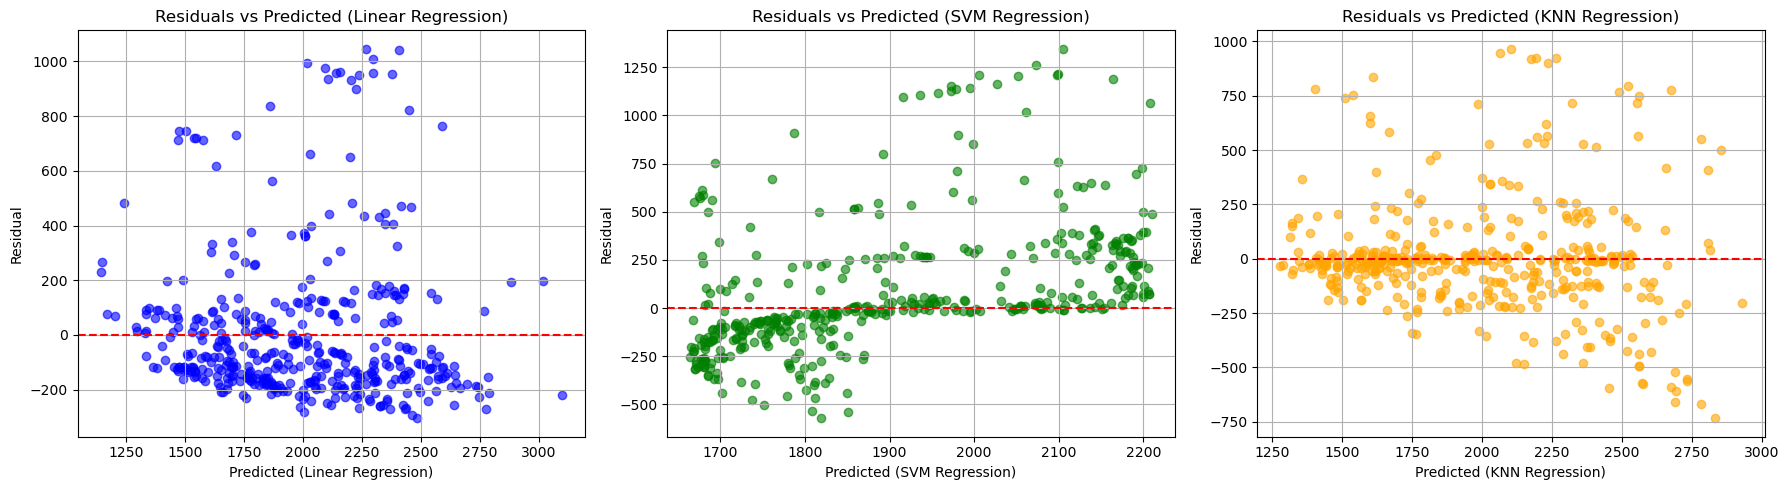

In [28]:
plt.figure(figsize=(18,5))

# Linear Regression
plt.subplot(1,3,1)
plt.scatter(y_pred_lr, residuals_lr, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted (Linear Regression)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Linear Regression)')
plt.grid(True)

# SVM Regression
plt.subplot(1,3,2)
plt.scatter(y_pred_svr, residuals_svr, color='green', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted (SVM Regression)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (SVM Regression)')
plt.grid(True)

# 3️⃣ KNN Regression
plt.subplot(1,3,3)
plt.scatter(y_pred_knn, residuals_knn, color='orange', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted (KNN Regression)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (KNN Regression)')
plt.grid(True)

plt.tight_layout()
plt.show()
